Пишем код для учета атмосферной рефракции в приближении плоско-параллельной атмосферы

In [25]:
from math import *
import numpy as np
from datetime import datetime
from astropy.time import Time

from astropy.coordinates import EarthLocation, AltAz, SkyCoord
import astropy.units as u
from astropy.time import Time

import matplotlib.pyplot as plt

def tangFromRADE(ra, dec, RA, DEC):
    ksi = cos(dec)*sin(ra-RA)/(sin(dec)*sin(DEC)+cos(dec)*cos(DEC)*cos(ra-RA))
    eta = (sin(dec)*cos(DEC)-cos(dec)*sin(DEC)*cos(ra-RA))/(sin(dec)*sin(DEC)+cos(dec)*cos(DEC)*cos(ra-RA))
    return ksi,eta

def RADecFromTang(ksi, eta, RA, Dec):
    x,y,z = np.dot(np.array([[-sin(RA),-cos(RA) * sin(Dec),cos(RA) * cos(Dec)],
                             [cos(RA),-sin(RA) * sin(Dec),sin(RA) * cos(Dec)],
                             [0,cos(Dec),sin(Dec)]]),
                   np.array([ksi,eta,1]))/sqrt(1+ksi*ksi+eta*eta)
    ra = atan2(y,x)
    dec = atan2(z,sqrt(x*x+y*y))
    if(ra<0):
        ra+=2*pi
    return ra,dec

# это функция для вычисления звездного времени
def getSiderial(JD, lon):
    MJD = JD - 2400000.5
    H = (MJD - trunc(MJD))*24.0
    D = JD - 2451545.0
    D0 = trunc(MJD) - 51544.5
    T = D/36525
    LST = 6.697374558 + 0.06570982441908*D0 + 1.00273790935*H + 0.000026*T*T+degrees(lon)/15
    return pi*(LST - 24.0*trunc(LST/24.0))/12.0

def RADECtoAzEl(ra, dec, s, lat):
    H = np.mod(s - ra, 2.0 * np.pi)
    x = np.cos(dec) * np.sin(H)
    y = np.sin(dec) * np.cos(lat) - np.cos(dec) * np.cos(H) * np.sin(lat)
    z = np.sin(dec) * np.sin(lat) + np.cos(dec) * np.cos(H) * np.cos(lat)

    az = np.arctan2(x, y)
    el = np.arctan2(z, np.hypot(x, y))
    return az, el

def AzEltoRADEC(az, el, s, lat):
    x = np.cos(el) * np.sin(az)
    y = np.cos(el) * np.cos(az)
    z = np.sin(el)

    dec = np.arcsin(np.sin(lat) * z + np.cos(lat) * y)
    HA = np.arctan2(x, np.cos(lat) * z - np.sin(lat) * y)
    ra = np.mod(s - HA, 2.0 * np.pi)
    return ra, dec


In [4]:
def refraction(ra,dec, s, lat, JD, t, P, wl):
    az, h = RADECtoAzEl(ra, dec, s, lat)
    zeta = np.pi/2.0 - h # from zenith
    # print(az, h)
    # print(f"zeta = {(zeta*u.rad).to(u.degree)}")

    k0 = 2.871e-4 * (1.0 + 5.67e-3 / wl**2)
    #k0 = 0.002926
    k = k0 * (P/760) * (273 / (273+t))
    # print(f"k = {k}")
    rho = k * np.tan(zeta)
    # print(f"rho = {(rho*u.rad).to(u.arcsec)}")

    ra_ref, dec_ref = AzEltoRADEC(az, h+rho, s, lat)
    
    return ra_ref, dec_ref


In [7]:
# проверим что обратное преобразование обратно
A, h = RADECtoAzEl(np.radians(50.0), np.radians(20.0), np.pi/4.0, np.radians(65.0))

ra, dec = AzEltoRADEC(A, h, np.pi/4.0, np.radians(65.0))
print(np.degrees(ra), np.degrees(dec))


-3.0257567240102365 0.7832632749633218
50.00000000000001 20.0


In [5]:
lon = radians(30.327498)
lat = radians(59.771831)
P = 750 # mmhg
t = 7 # celsius
wl = 0.55 # mcm
ra,dec = radians(60.0),radians(-20.0)
JD = float(Time('2026-05-27 23:00:00').copy(format='jd').value)
print(JD)

2461188.4583333335


In [6]:
# просто потренируйтесь вычислять координаты, исправленные за влияние атмосферной рефракции
ra,dec = radians(50), radians(20)
s = getSiderial(JD,lon)
ra_ref, dec_ref = refraction(ra,dec,s,lat,JD,t,P,wl) * u.rad
print(ra_ref.to(u.deg).value, dec_ref.to(u.deg).value)

-0.5059841486443397 -0.11091370392125854
zeta = 96.35488712485173 deg
k = 0.00028141708403110044
rho = -521.199965681375 arcsec
50.039970741985115 19.860183754535395


Допустим звезда имеет координаты ra,dec = s,30 (s - звездное время) в начальный момент наблюдений. Околоземный астероид проходит вблизи звезды и его координаты меняются линейно со временем. В момент s тангенциальные координаты астероида составляют $\xi,\eta = 5,5\, arcsec$ без учета атмосферной рефракции. Компоненты скорости астероида $\dot \xi, \dot \eta = 24,17 \,arcsec/hour$. Звезда имеет максимум излучения в спектре на длине волны $\lambda_s = 500\, нм$, астероид - $\lambda_a = 650\, нм$. Условия наблюдений ($P = 556\, мм.рт.ст., t = 3^\circ C$). Построить траектории астероида относительно звезды в тангенциальных координатах с учетом рефракции и без ее учета на протяжении трех часов после начала наблюдений. Оценить, насколько значим эффект атмосферной рефракции для точной астрометрии околоземных астероидов? 

In [50]:
JD = float(Time('2026-05-27 23:00:00').copy(format='jd').value)
s = getSiderial(JD,lon)
ra_s = s
dec_s = 30

xi0 = eta0 = 5.5 * u.arcsec
v_xi = v_eta = 24.17 * u.arcsec / u.hour

wl_s = 0.500
wl_a = 0.650
P = 556
t = +3

In [51]:
minutes = np.arange(0, 3*60 + 5, 5)
jd_list = JD + minutes / (24 * 60)
jd_list = list(jd_list)

xi_list = [
    (xi0 + v_xi * ((jd - jd_list[0]) * u.day).to(u.hour)).value
    for jd in jd_list
]

eta_list = [
    (eta0 + v_eta * ((jd - jd_list[0]) * u.day).to(u.hour)).value
    for jd in jd_list
]

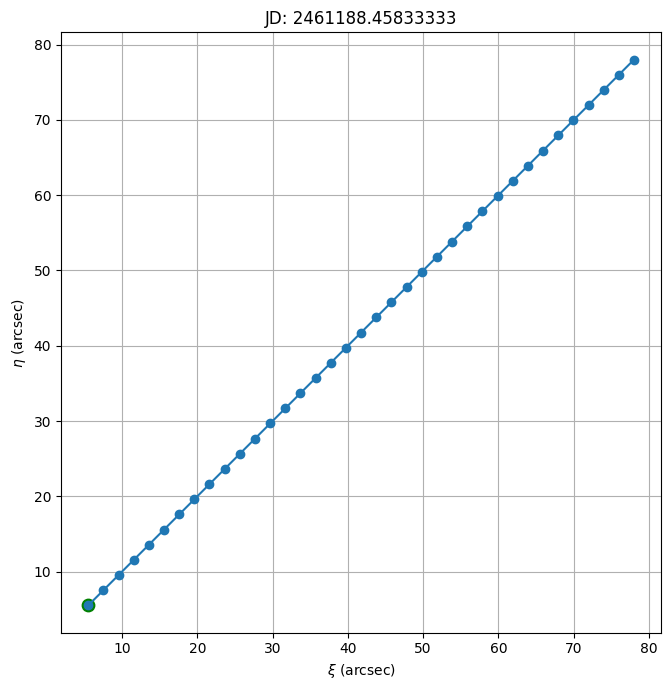

In [52]:
fig, ax = plt.subplots(figsize=(7, 7))

ax.plot(xi_list, eta_list, "o-")
ax.scatter(xi_list[0], eta_list[0], color="green", s=80, label="Start")

ax.set_title(f"JD: {JD:.8f}")
ax.set_xlabel(r"$\xi$ (arcsec)")
ax.set_ylabel(r"$\eta$ (arcsec)")
ax.set_aspect("equal", adjustable="box")
ax.grid(True)

plt.tight_layout()
plt.show()


In [53]:

ra_s_ref = []
dec_s_ref = []

dec_s_rad = radians(dec_s)

for jd in jd_list:
    s_i = getSiderial(jd, lon)

    ra_ref_i, dec_ref_i = refraction(
        ra=s_i,
        dec=dec_s_rad,
        s=s_i,
        lat=lat,
        JD=jd,
        t=t,
        P=P,
        wl=wl_s,
    )

    ra_s_ref.append(ra_ref_i)
    dec_s_ref.append(dec_ref_i)

3.141592653589793 1.0511798514975805
zeta = 29.771831000000006 deg
k = 0.0002124651574812357
rho = 25.069685341996006 arcsec
3.141592653589793 1.0511798514975805
zeta = 29.771831000000006 deg
k = 0.0002124651574812357
rho = 25.069685341996006 arcsec
3.141592653589793 1.0511798514975805
zeta = 29.771831000000006 deg
k = 0.0002124651574812357
rho = 25.069685341996006 arcsec
3.141592653589793 1.0511798514975805
zeta = 29.771831000000006 deg
k = 0.0002124651574812357
rho = 25.069685341996006 arcsec
3.141592653589793 1.0511798514975805
zeta = 29.771831000000006 deg
k = 0.0002124651574812357
rho = 25.069685341996006 arcsec
3.141592653589793 1.0511798514975805
zeta = 29.771831000000006 deg
k = 0.0002124651574812357
rho = 25.069685341996006 arcsec
3.141592653589793 1.0511798514975805
zeta = 29.771831000000006 deg
k = 0.0002124651574812357
rho = 25.069685341996006 arcsec
3.141592653589793 1.0511798514975805
zeta = 29.771831000000006 deg
k = 0.0002124651574812357
rho = 25.069685341996006 arcsec


In [57]:
s_list = [getSiderial(jd, lon) for jd in jd_list]

xi_ref = []
eta_ref = []
for i in range(len(xi_list)):
    ra_a, dec_a = RADecFromTang(xi_list[i], eta_list[i], ra_s, dec_s)
    ra_a_ref, dec_a_ref = refraction(ra_a, dec_a, s_list[i], lat, jd_list[i], t, P, wl_a)
    xi_ref_i, eta_ref_i = tangFromRADE(ra_a_ref, dec_a_ref, ra_s_ref[i], dec_s_ref[i])

    xi_ref.append(xi_ref_i)
    eta_ref.append(eta_ref_i)


-2.2984502927360406 0.35050670991873845
zeta = 69.91744483064005 deg
k = 0.00021054138639500086
rho = 118.78266508357663 arcsec
-2.302891277364166 0.388683200760113
zeta = 67.73009302880946 deg
k = 0.00021054138639500086
rho = 106.04525880516778 arcsec
-2.3148195082619014 0.4142480859877111
zeta = 66.26533300153173 deg
k = 0.00021054138639500086
rho = 98.76768899376395 arcsec
-2.3305068799790156 0.4336886422232323
zeta = 65.15147117784964 deg
k = 0.00021054138639500086
rho = 93.77656177681502 arcsec
-2.3483920430700014 0.4496517956410996
zeta = 64.23684985928601 deg
k = 0.00021054138639500086
rho = 89.98128327817439 arcsec
-2.3677066304129872 0.4634156698084772
zeta = 63.44823795974612 deg
k = 0.00021054138639500086
rho = 86.90494235654982 arcsec
-2.3880287943383616 0.47567114505261615
zeta = 62.74605095232991 deg
k = 0.00021054138639500086
rho = 84.30499592135367 arcsec
-2.4091076825137456 0.4868230286241803
zeta = 62.107095090057996 deg
k = 0.00021054138639500086
rho = 82.04442212032

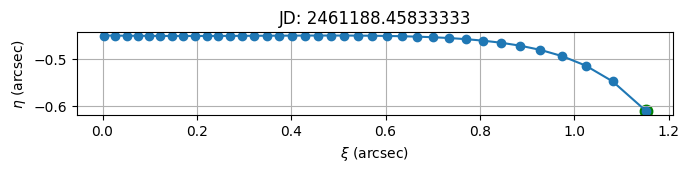

In [58]:
fig, ax = plt.subplots(figsize=(7, 7))

ax.plot(xi_ref, eta_ref, "o-")
ax.scatter(xi_ref[0], eta_ref[0], color="green", s=80, label="Start")

ax.set_title(f"JD: {JD:.8f}")
ax.set_xlabel(r"$\xi$ (arcsec)")
ax.set_ylabel(r"$\eta$ (arcsec)")
ax.set_aspect("equal", adjustable="box")
ax.grid(True)

plt.tight_layout()
plt.show()



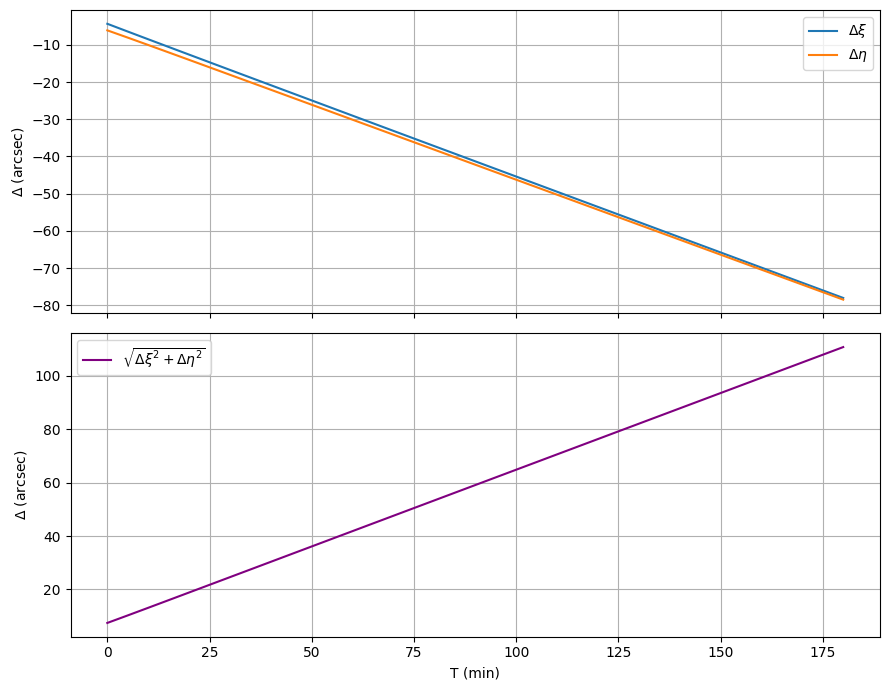

Max abs delta xi: 78.007 arcsec
Max abs delta eta: 78.460 arcsec
Max abs difference: 110.639 arcsec


In [59]:
xi = np.asarray(xi_list)
eta = np.asarray(eta_list)
xi_r = np.asarray(xi_ref)
eta_r = np.asarray(eta_ref)

d_xi = xi_r - xi
d_eta = eta_r - eta
d_dist = np.hypot(d_xi, d_eta)

fig, axes = plt.subplots(2, 1, figsize=(9, 7), sharex=True)

axes[0].plot(minutes, d_xi, "-", label=r"$\Delta\xi$")
axes[0].plot(minutes, d_eta, "-", label=r"$\Delta\eta$")
axes[0].set_ylabel("$\Delta$ (arcsec)")
axes[0].grid(True)
axes[0].legend()

axes[1].plot(minutes, d_dist, "-", color="purple", label=r"$\sqrt{\Delta\xi^2+\Delta\eta^2}$")
axes[1].set_xlabel("T (min)")
axes[1].set_ylabel("$\Delta$ (arcsec)")
axes[1].grid(True)
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Max abs delta xi: {np.max(np.abs(d_xi)):.3f} arcsec")
print(f"Max abs delta eta: {np.max(np.abs(d_eta)):.3f} arcsec")
print(f"Max abs difference: {np.max(d_dist):.3f} arcsec")